# Importing all the libraries for mnsit digit classification using ann and cnn models and all the supervised machine learning models

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader,TensorDataset

In [3]:
#MNIST contains 28×28 grayscale handwritten digit images (0–9).
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target
y = y.astype(int)
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


## Visualization of data

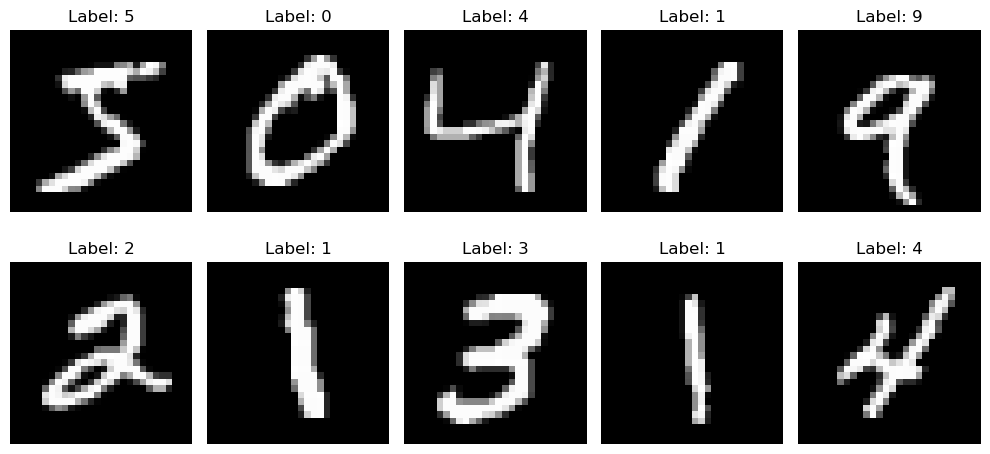

In [4]:
#Seeing the data 
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

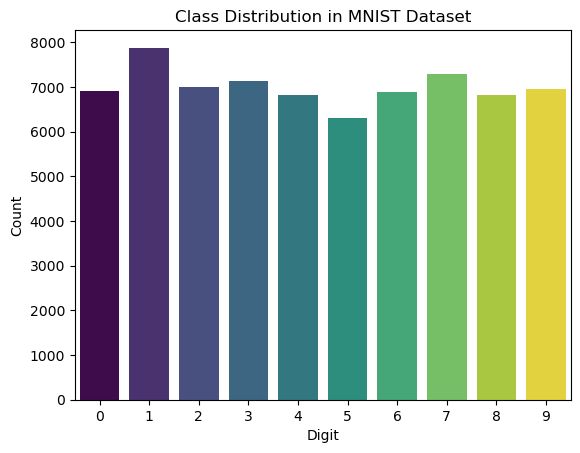

In [5]:
# check class distribution

# count the occurance of each class
unique,counts = np.unique(y, return_counts=True)
class_distribution = pd.DataFrame({'Digit': unique, 'Count': counts})

sns.barplot(
    x='Digit',
    y='Count',
    data=class_distribution,
    hue='Digit',
    palette='viridis',
    legend=False
)
plt.title('Class Distribution in MNIST Dataset')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.show()

## Checking data for there distrubution

In [6]:
mean_intensity = np.mean(X)
std_intensity = np.std(X)
max_intensity = np.max(X)
min_intensity = np.min(X)

print(f"mean_intensity: {mean_intensity}")
print(f"std_intensity: {std_intensity}")
print(f"max_intensity: {max_intensity}")
print(f"min_intensity: {min_intensity}")

# checking missing values
print(np.isnan(X).sum())
print(np.isnan(y).sum())

mean_intensity: 33.385964741253645
std_intensity: 78.65437362689416
max_intensity: 255
min_intensity: 0
0
0


## Preprocessign the data for traning

In [7]:
#Reshape for deep learning models(add channel dimension)
#As 4D
x_dl =X.reshape(X.shape[0], 28,28,1)
#reshaping for machine learning (2d to 1d)
x_flat = X.reshape(X.shape[0], -1)
print("Shape for ML models:", x_flat.shape)
print("Shape for DL models:", x_dl.shape)

Shape for ML models: (70000, 784)
Shape for ML models: (70000, 28, 28, 1)


In [8]:
#splitting data into traning and testing
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_flat, y, test_size= 0.2, random_state = 42)
print("Training set shape:", x_train.shape, y_train.shape)
print("Test set shape:", x_test.shape, y_test.shape)

x_train_dl, x_test_dl, y_train_dl, y_test_dl = train_test_split(
    x_dl,
    y,
    test_size=0.2,
    random_state=42
)

Training set shape: (56000, 784) (56000,)
Test set shape: (14000, 784) (14000,)


In [9]:
#normalization and converting to tensor for cnn 
x_train_dl = torch.tensor(
    x_train.reshape(-1, 1, 28, 28),
    dtype=torch.float32
) / 255.0

x_test_dl = torch.tensor(
    x_test.reshape(-1, 1, 28, 28),
    dtype=torch.float32
) / 255.0

y_train_dl = torch.tensor(y_train_dl, dtype=torch.long)
y_test_dl = torch.tensor(y_test_dl, dtype=torch.long)

## Training the data for ANN and CNN

### 1.For CNN

In [10]:
#Making the trainset and booting the data
trainset = TensorDataset(x_train_dl, y_train_dl)
testset = TensorDataset(x_test_dl, y_test_dl)

trainloader = DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

testloader = DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)


In [11]:
x_train_dl.shape

torch.Size([56000, 1, 28, 28])

In [12]:
#Making the cnn model
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.convu_layer=nn.Sequential(
            #input layer
            nn.Conv2d(1,32,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            #first hidden layer
            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            #second hidden layer
            nn.Conv2d(64,128,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )
        self.fc_layer=nn.Sequential(
            nn.Linear(1152, 256),
            nn.ReLU(),
            nn.Linear(256,10),
        )
    def forward(self,x):
        x=self.convu_layer(x)
        x=x.view(x.size(0),-1)
        x= self.fc_layer(x)
        return x

In [13]:
#calling cnn model and defining the parameters for training
model=CNN()
optimizer=optim.Adam(model.parameters())
criteria=nn.CrossEntropyLoss()

In [14]:
#Traning the CNN model
epochs=10
model.train()
for epoch in range(epochs):
    epoch_training_loss = 0.0
    for xb,yb in trainloader:
        optimizer.zero_grad()
        output=model(xb)
        loss=criteria(output,yb)
        loss.backward()
        optimizer.step()
        epoch_training_loss += loss.item()

    print(f"epoch{epoch} & loss{epoch_training_loss/len(trainloader)}")

epoch0 & loss0.18864618723147683
epoch1 & loss0.04674846177574779
epoch2 & loss0.03309605972992722
epoch3 & loss0.0241090740912228
epoch4 & loss0.021323645070902005
epoch5 & loss0.015582828594716765
epoch6 & loss0.015265305083039233
epoch7 & loss0.012569813394853553
epoch8 & loss0.010935383236921552
epoch9 & loss0.008969122700923565


In [15]:
## Evaluting on train set and test set for underfitting and overfitting
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    # ---- TRAIN ----
    model.train()

    correct = 0
    total = 0

    for images, labels in trainloader:
        optimizer.zero_grad()

        output = model(images)
        loss = criteria(output, labels)

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(output, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_accuracy = correct / total * 100
    train_accuracies.append(train_accuracy)


    # ---- VALIDATION ----
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            output = model(images)
            _, predicted = torch.max(output, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_accuracy = correct / total * 100
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch+1}: "
        f"Train Accuracy = {train_accuracy:.2f}% | "
        f"Validation Accuracy = {val_accuracy:.2f}%"
    )

Epoch 1: Train Accuracy = 99.72% | Validation Accuracy = 99.09%
Epoch 2: Train Accuracy = 99.72% | Validation Accuracy = 99.00%
Epoch 3: Train Accuracy = 99.71% | Validation Accuracy = 98.77%
Epoch 4: Train Accuracy = 99.76% | Validation Accuracy = 99.04%
Epoch 5: Train Accuracy = 99.83% | Validation Accuracy = 99.14%
Epoch 6: Train Accuracy = 99.85% | Validation Accuracy = 98.95%
Epoch 7: Train Accuracy = 99.84% | Validation Accuracy = 99.12%
Epoch 8: Train Accuracy = 99.81% | Validation Accuracy = 98.99%
Epoch 9: Train Accuracy = 99.88% | Validation Accuracy = 99.12%
Epoch 10: Train Accuracy = 99.88% | Validation Accuracy = 99.12%


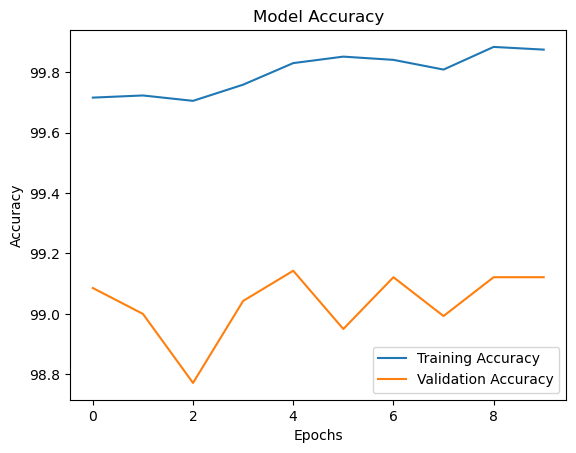

In [16]:
#Showing the relation between traning and validation accuracy for correcting underfit or overfit
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

### 2.ANN

In [25]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        self.model=nn.Sequential(
            #input layer
            nn.Linear(X.shape[1],64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,10), 
        )
    def forward(self,x):
            return self.model(x)

In [28]:
X.shape[1]

784

In [35]:
model_ann=ANN()
optimizer = torch.optim.Adam(
    model_ann.parameters(),
    lr=0.001
)

In [36]:
epochs=30
model_ann.train()
for epoch in range(epochs):
    epoch_training_loss = 0.0
    for xb,yb in trainloader:
        xb = xb.view(xb.size(0), -1)  # (64, 28, 28) → (64, 784)
        optimizer.zero_grad()
        output=model_ann(xb)
        loss=criteria(output,yb)
        loss.backward()
        optimizer.step()
        epoch_training_loss += loss.item()

    print(f"epoch{epoch} & loss{epoch_training_loss/len(trainloader)}")

epoch0 & loss0.39575569535153254
epoch1 & loss0.18029728602085796
epoch2 & loss0.12924000047360149
epoch3 & loss0.10152746984948005
epoch4 & loss0.08199078231464539
epoch5 & loss0.06821224076992699
epoch6 & loss0.05791478322419737
epoch7 & loss0.0489189551025629
epoch8 & loss0.04171027661753552
epoch9 & loss0.038138062344730966
epoch10 & loss0.030883554413382495
epoch11 & loss0.028495028812305204
epoch12 & loss0.02400388996928398
epoch13 & loss0.021285265119945898
epoch14 & loss0.019944463932986503
epoch15 & loss0.018589695777594378
epoch16 & loss0.015053349840354972
epoch17 & loss0.015323259437722819
epoch18 & loss0.013642154869739898
epoch19 & loss0.010159187009537293
epoch20 & loss0.013792582454974764
epoch21 & loss0.010064759636100332
epoch22 & loss0.012016906047998679
epoch23 & loss0.008988150223142708
epoch24 & loss0.009137488868486669
epoch25 & loss0.009147391219630662
epoch26 & loss0.007762477753793064
epoch27 & loss0.010700113644528235
epoch28 & loss0.007677054825274224
epoch2

In [38]:
## Evaluting on train set and test set for underfitting and overfitting
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    # ---- TRAIN ----
    model_ann.train()

    correct = 0
    total = 0

    for images, labels in trainloader:
        optimizer.zero_grad()
        images = images.view(images.size(0), -1)
        output = model_ann(images)
        loss = criteria(output, labels)

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(output, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_accuracy = correct / total * 100
    train_accuracies.append(train_accuracy)


    # ---- VALIDATION ----
    model_ann.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images = images.view(images.size(0), -1)
            output = model_ann(images)
            _, predicted = torch.max(output, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_accuracy = correct / total * 100
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch+1}: "
        f"Train Accuracy = {train_accuracy:.2f}% | "
        f"Validation Accuracy = {val_accuracy:.2f}%"
    )

Epoch 1: Train Accuracy = 99.79% | Validation Accuracy = 97.00%
Epoch 2: Train Accuracy = 99.77% | Validation Accuracy = 97.12%
Epoch 3: Train Accuracy = 99.74% | Validation Accuracy = 97.36%
Epoch 4: Train Accuracy = 99.83% | Validation Accuracy = 97.19%
Epoch 5: Train Accuracy = 99.64% | Validation Accuracy = 97.32%
Epoch 6: Train Accuracy = 99.87% | Validation Accuracy = 97.36%
Epoch 7: Train Accuracy = 99.92% | Validation Accuracy = 97.37%
Epoch 8: Train Accuracy = 99.59% | Validation Accuracy = 97.19%
Epoch 9: Train Accuracy = 99.89% | Validation Accuracy = 97.47%
Epoch 10: Train Accuracy = 99.75% | Validation Accuracy = 96.96%
Epoch 11: Train Accuracy = 99.74% | Validation Accuracy = 97.11%
Epoch 12: Train Accuracy = 99.90% | Validation Accuracy = 97.43%
Epoch 13: Train Accuracy = 99.67% | Validation Accuracy = 97.21%
Epoch 14: Train Accuracy = 99.84% | Validation Accuracy = 97.21%
Epoch 15: Train Accuracy = 99.76% | Validation Accuracy = 97.26%
Epoch 16: Train Accuracy = 99.90% 

## Training data for ml models

### 1.Logistic Classification

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
lr = LogisticRegression(max_iter=5000)
lr.fit(x_train,y_train)

In [ ]:
y_pred = lr.predict(x_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

### 2.KNeighborsClassifier

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# Tune the value of K using GridSearchCV
# to obtain the best-performing model.
classifier=KNeighborsClassifier()
parameter={"n_neighbors":[3,5,7,6,8,9]}
gridcv=GridSearchCV(
    classifier,
    parameter,
    cv=5
)
gridcv.fit(X_train_scale,y_train)

In [ ]:
y_pred = lr.predict(x_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

### 3.GaussianNB

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
nb=GaussianNB()
nb.fit(X_train,y_train)

In [ ]:
y_pred = lr.predict(x_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))